## Overview

We will conduct case studies on the following two datasets for dimension reduction in this seminar:
* Optical recognition of handwritten digits dataset.
* Ames Housing dataset.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_digits

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate
from sklearn.preprocessing import StandardScaler

The data set contains images of hand-written digits: 10 classes where each class refers to a digit.

Shape of the dataset:  (1797, 64)


<Figure size 640x480 with 0 Axes>

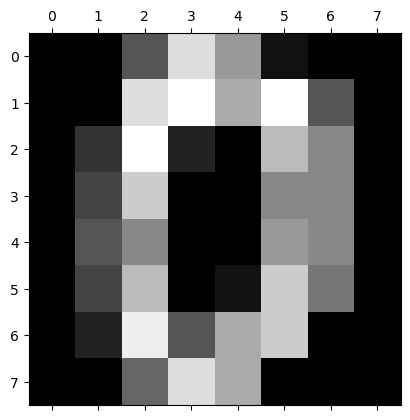

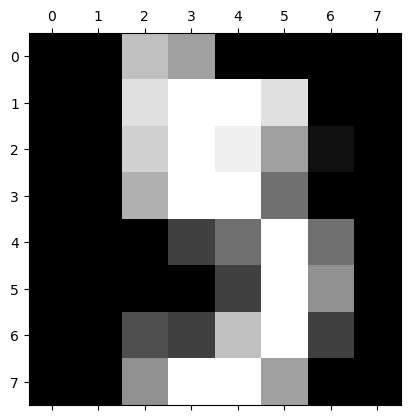

In [3]:
digits = load_digits()
print("Shape of the dataset: " , digits.data.shape)
plt.gray()
plt.matshow(digits.images[0])
plt.matshow(digits.images[5])

In [4]:
X_digits, y_digits = digits.data, digits.target
y_digits = y_digits.astype(str)

Standardize predictors (features) by removing the mean and scaling to unit variance. 

In [5]:
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

### PCA

Apply PCA with default parameters. The number of components is min(n_samples, n_features) - 1.

In [6]:
default_pca = PCA()
default_pca.fit(X_digits_scaled)

PCA()

From a fitted model, we can see how much variance each component explains by using the *.explained_variance_ratio_* attribute.

In [238]:
print(default_pca.explained_variance_ratio_)

[1.20339161e-01 9.56105440e-02 8.44441489e-02 6.49840791e-02
 4.86015488e-02 4.21411987e-02 3.94208280e-02 3.38938092e-02
 2.99822101e-02 2.93200255e-02 2.78180546e-02 2.57705509e-02
 2.27530332e-02 2.22717974e-02 2.16522943e-02 1.91416661e-02
 1.77554709e-02 1.63806927e-02 1.59646017e-02 1.48919119e-02
 1.34796957e-02 1.27193137e-02 1.16583735e-02 1.05764660e-02
 9.75315947e-03 9.44558990e-03 8.63013827e-03 8.36642854e-03
 7.97693248e-03 7.46471371e-03 7.25582151e-03 6.91911245e-03
 6.53908536e-03 6.40792574e-03 5.91384112e-03 5.71162405e-03
 5.23636803e-03 4.81807586e-03 4.53719260e-03 4.23162753e-03
 4.06053070e-03 3.97084808e-03 3.56493303e-03 3.40787181e-03
 3.27835335e-03 3.11032007e-03 2.88575294e-03 2.76489264e-03
 2.59174941e-03 2.34483006e-03 2.18256858e-03 2.03597635e-03
 1.95512426e-03 1.83318499e-03 1.67946387e-03 1.61236062e-03
 1.47762694e-03 1.35118411e-03 1.25100742e-03 1.03695730e-03
 8.25350945e-04 3.23475858e-33 6.39352227e-34 6.29595280e-34]


We create a DataFrame that includes each PCA, its explained variance, and the cumulative sum of the PCAs.

In [228]:
expl_var = default_pca.explained_variance_ratio_
df_expl_var = pd.DataFrame(
    data=zip(range(1, len(expl_var) + 1), expl_var, expl_var.cumsum()), 
    columns=['PCA', 'Explained Variance (%)', 'Total Explained Variance (%)']
    ).set_index('PCA').mul(100).round(1)
df_expl_var.head()

,Explained Variance (%),Total Explained Variance (%)
PCA,,
1,12.0,12.0
2,9.6,21.6
3,8.4,30.0
4,6.5,36.5
5,4.9,41.4


Plot the dataset *df_expl_var* to get a better sense of it.

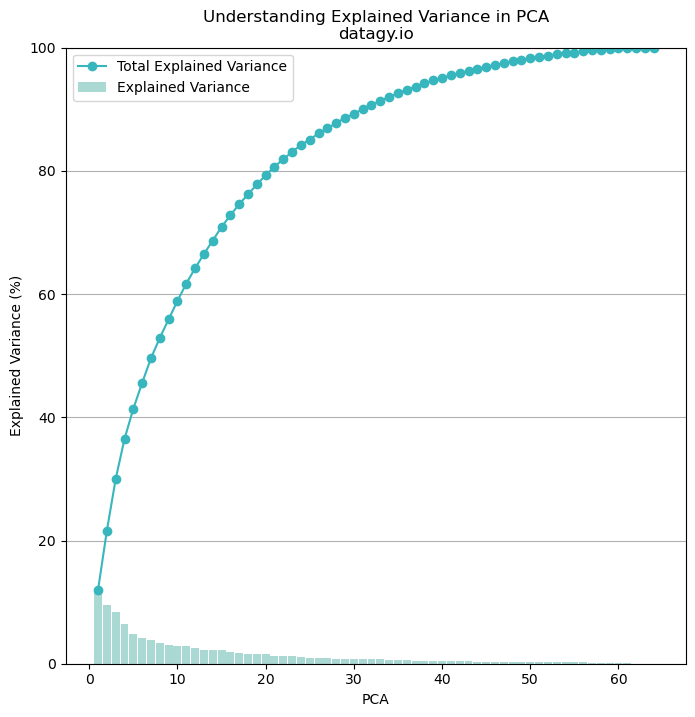

In [229]:
fig, ax = plt.subplots(figsize=(8,8))
ax.bar(x=df_expl_var.index, height=df_expl_var['Explained Variance (%)'], label='Explained Variance', width=0.9, color='#AAD8D3')
ax.plot(df_expl_var['Total Explained Variance (%)'], label='Total Explained Variance', marker='o', c='#37B6BD')

plt.ylim(0, 100)
plt.ylabel('Explained Variance (%)')
plt.xlabel('PCA')
plt.grid(True, axis='y')
plt.title('Understanding Explained Variance in PCA\ndatagy.io')
plt.legend()

In [88]:
pca = PCA(n_components = 2)
X_digits_pca = pca.fit_transform(X_digits)

#### Understand Loadings in PCA 

Loading scores are the coefficients assigned to each original variables in the linear combinations that form each principal component.

Loading scores reveal information about the influence of one variable on a principal component:

* Large loading values (either positive or negative) indicate that the corresponding original variable has a strong influence on that particular principal component.
* Small loading values indicate that the original variable has a weaker influence on the principal component.
* Loadings close to zero suggest that the original variable has little relevance to the formation of that principal component.

We can access the loading scores for each principal component by using the *.components_* attribute.

In [230]:
print(pca.components_)

[[-3.33066907e-16 -1.82234096e-01 -2.85867855e-01 -2.20369508e-01
   2.51693214e-02  9.49710578e-03  5.24764907e-02  6.26950155e-02
  -3.47072397e-02 -2.45533876e-01 -2.29151708e-01  1.07943668e-01
  -3.62023545e-02 -3.87117570e-02  8.37807702e-02  9.27750117e-02
  -1.66989989e-02 -1.36716769e-01  6.30506668e-02  1.22879324e-01
  -1.48193477e-01  2.34841470e-02  1.71199715e-01  1.04208327e-01
   3.94916975e-03  1.16389574e-01  1.88204690e-01 -6.58602305e-02
  -1.43532484e-01  1.28207035e-01  1.80620753e-01  5.27090831e-02
  -0.00000000e+00  2.38902567e-01  2.35006121e-01  5.09133396e-03
   1.31088056e-02  1.59116250e-01  1.29394134e-01 -0.00000000e+00
   5.55991658e-02  1.87157208e-01  1.53533679e-01  4.68255745e-02
   1.10892729e-01  1.07209555e-01 -1.79266131e-02  2.27266713e-03
   2.88172086e-02 -4.08678834e-02 -1.10270664e-01 -3.18246183e-02
   7.90494168e-02 -6.83215182e-02 -1.21247224e-01 -4.87711295e-02
   1.83569329e-03 -1.60395853e-01 -2.79852891e-01 -1.94449076e-01
  -1.77738

Since we only have two components, it is helpful to visualize them in a scatterplot.

In [148]:
def plot_dr_scatter(dr_X, y):
    # Plot the result of our TSNE with the label color coded
    # A lot of the stuff here is about making the plot look pretty and not TSNE
    dr_result_df = pd.DataFrame({'dr_1': dr_X[:,0], 'dr_2': dr_X[:,1], 'label': y})
    fig, ax = plt.subplots(1)
    sns.scatterplot(x='dr_1', y='dr_2', hue='label', data=dr_result_df, ax=ax,s=80)
    lim = (dr_X.min()-5, dr_X.max()+5)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    plt.xlabel('First Component')
    plt.ylabel('Second Component')
    #ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

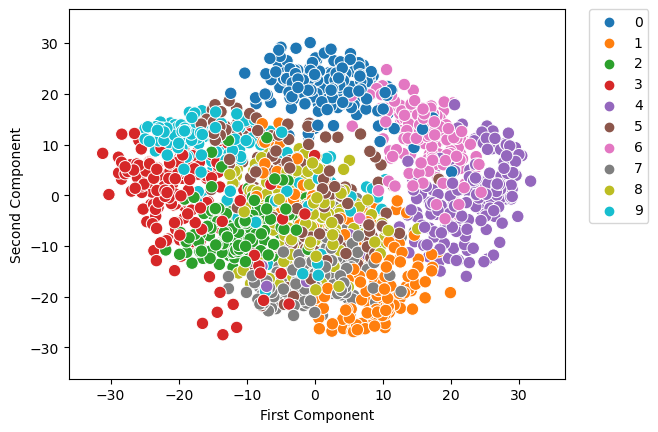

In [146]:
plot_dr_scatter(X_digits_pca, y_digits)

#### Activity 1
Apply PCA to the scaled dataset *X_digits_scaled* and compare its plot with the one without using the scaled dataset.

In [133]:
X_digits_scaled_pca = pca.fit_transform(X_digits_scaled)

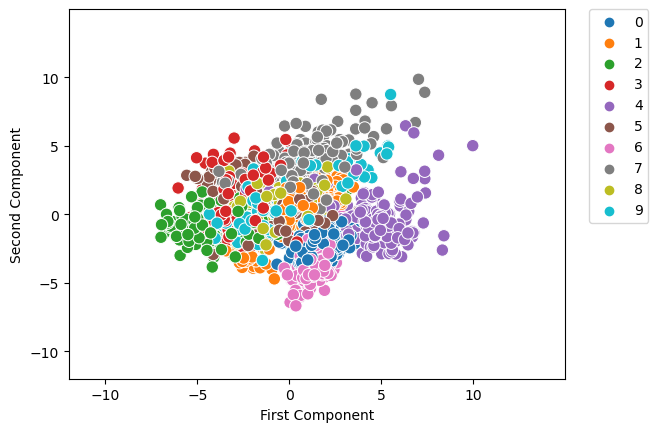

In [147]:
plot_dr_scatter(X_digits_scaled_pca, y_digits)

### T-SNE
Apply T-SNE to the digits dataset.

In [112]:
n_components = 2
tsne = TSNE(n_components,init='pca')
tsne_digits = tsne.fit_transform(X_digits)

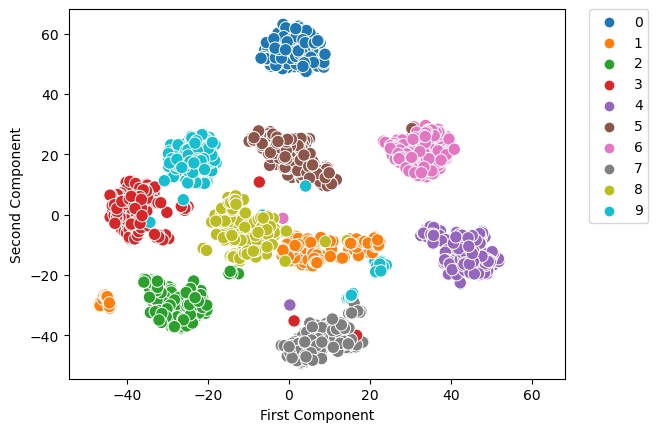

In [149]:
plot_dr_scatter(tsne_digits, y_digits)

## Case Study II: Ames Housing Dataset

In [160]:
df_ames = pd.read_csv("Ames_numeric-10-binary.csv")
X_ames = df_ames.drop(columns='SalePrice')
y_ames = df_ames['SalePrice']
X_ames_train, X_ames_test, y_ames_train, y_ames_test = train_test_split(
    X_ames, y_ames, test_size=0.2, random_state=42)

In [161]:
scaled_ames_train = scaler.fit_transform(X_ames_train)
X_ames_pca = pca.fit_transform(scaled_ames_train)

Apply PCA and T-SNE to this dataset.

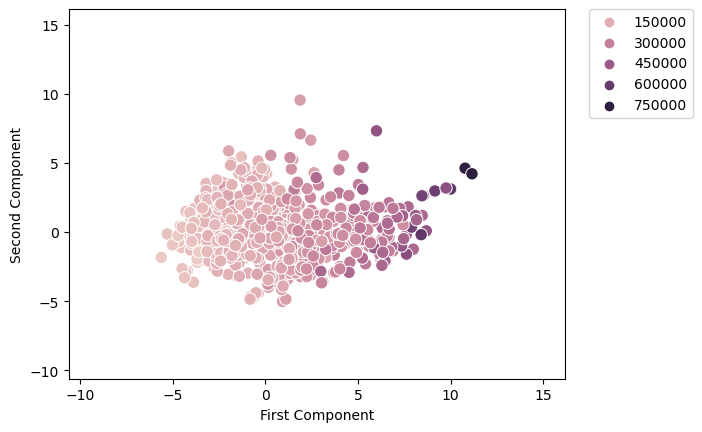

In [162]:
plot_dr_scatter(X_ames_pca,y_ames_train)

In [220]:
tsne_ames = tsne.fit_transform(scaled_ames_train)

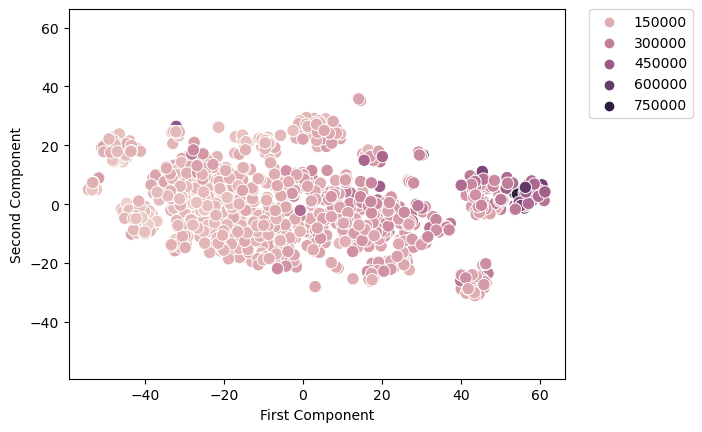

In [221]:
plot_dr_scatter(tsne_ames,y_ames_train)

#### Compare PCR with linear regression and Lasso.

In [175]:
lr = LinearRegression()
rmse_lr = -cross_val_score(lr, X_ames_train, y_ames_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_lr.mean(), rmse_lr.std()))

RMSE: 27501.57 ; Standard deviation : 2217.14


In [179]:
lasso = Lasso(alpha=10)
cv_lasso = -cross_val_score(lasso, X_ames_train, y_ames_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (cv_lasso.mean(), cv_lasso.std()))

RMSE: 27491.80 ; Standard deviation : 2208.40


Create a PCR pipeline that consists of a PCA model and a linear regression model. 

In [212]:
pcr = Pipeline([
    ('pca', PCA(n_components=2)),
    ('linear_regression', LinearRegression())
])

In [213]:
rmse_pcr = -cross_val_score(pcr, X_ames_train, y_ames_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_pcr.mean(), rmse_pcr.std()))

RMSE: 75149.70 ; Standard deviation : 9462.42


In [214]:
rmse_pcr = -cross_val_score(pcr, scaled_ames_train, y_ames_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_pcr.mean(), rmse_pcr.std()))

RMSE: 35250.86 ; Standard deviation : 4094.37


Identify the best number of components for PCR by using grid search.

In [206]:
param_grid = {'pca__n_components': range(1, 46)}
grid = GridSearchCV(pcr,param_grid,cv=5,
scoring='neg_mean_squared_error')
grid.fit(scaled_ames_train,y_ames_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pca', PCA(n_components=2)),
                                       ('linear_regression',
                                        LinearRegression())]),
             param_grid={'pca__n_components': range(1, 46)},
             scoring='neg_mean_squared_error')

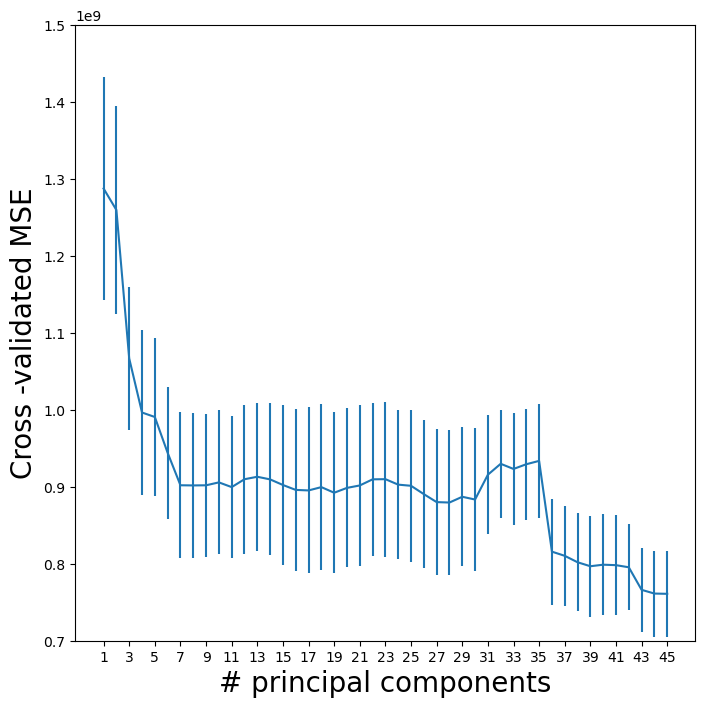

In [211]:
pcr_fig , ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp ,
-grid.cv_results_['mean_test_score'], yerr=grid.cv_results_['std_test_score']/np.sqrt(5))
ax.set_ylabel('Cross -validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp [::2])
ax.set_ylim ([7e+08 ,1.5e+09]);

#### After Class Activity

What is the RMSE using 5-fold cross-validation for the PCR model with the best hyperparameter?

In [208]:
pcr_best = Pipeline([
    ('pca', PCA(n_components=45)),
    ('linear_regression', LinearRegression())
])
rmse_pcr = -cross_val_score(pcr_best, scaled_ames_train, y_ames_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_pcr.mean(), rmse_pcr.std()))

RMSE: 27494.91 ; Standard deviation : 2222.99
